# Marketing A/B Test: Ad Attribution & Campaign ROI Analysis

**Dataset:** Marketing A/B Testing — Kaggle  

---

## Business Context

A marketing team ran a **controlled experiment** to measure the true impact of paid advertising on product conversions. Users were randomly split into two groups:

- **Ad Group** — saw the actual product advertisement
- **PSA Group** (control) — saw a Public Service Announcement in the same placement, same size

The PSA group is a methodologically sound control — it isolates the *ad content itself* as the variable, controlling for the mere exposure effect (the fact that seeing anything in an ad slot might influence behavior).

### The Two Questions We Must Answer

1. **Was the campaign statistically successful?** Did the ad group convert at a meaningfully higher rate than the control?
2. **How much revenue can we actually attribute to the ads?** This is the budget justification question — the difference between a campaign that *worked* and one that was *worth the spend*.

---

## Analytical Roadmap

| Act | Focus | Key Output |
|-----|-------|------------|
| 1 | Experiment Validation | Confirm the test was run correctly before trusting any results |
| 2 | EDA & Behavioral Profiling | Understand user patterns, ad frequency effects, timing |
| 3 | Hypothesis Testing | Statistical significance + effect size |
| 4 | Revenue Attribution Model | Incremental revenue attributable to ads |
| 5 | Executive Recommendations | Ship/No-Ship verdict + strategic actions |

---
# ACT 1: Experiment Validation

We will check three things:
1. **Data integrity** — Are there duplicates, nulls, or impossible values?
2. **Group balance (Sample Ratio Mismatch)** — Is the ad/PSA split what the experiment intended?
3. **Group contamination** — Did any user end up in both groups?

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'ad':      '#2563EB',   # blue  — the treatment group
    'psa':     '#94A3B8',   # grey  — the control group
    'accent':  '#16A34A',   # green — positive highlights
    'warning': '#DC2626',   # red   — risk/negative highlights
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


### 1.1 — Load & First Look

We load the raw dataset and performing an initial structural inspection.

**We expect:** ~580k+ rows, 7 columns, two distinct values in `test_group` ('ad' and 'psa'), and `converted` as a boolean. Any deviation from this is a signal to investigate.

In [18]:
df = pd.read_csv('/Users/tanasirenkaa/portfolio_project_3/marketing-ab-testing/data/marketing_ab_data.csv')

# Drop FIRST (before rename changes the column name)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Then rename spaces to underscores
df.columns = df.columns.str.replace(' ', '_')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumn dtypes:')
print(df.dtypes)
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: 588,101 rows × 6 columns

Column dtypes:
user_id           int64
test_group       object
converted          bool
total_ads         int64
most_ads_day     object
most_ads_hour     int64
dtype: object

First 5 rows:


,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


### 1.2 — Null & Duplicate Check

We scan for missing values and duplicate `user id` entries.

**Why this matters:**  
- **Nulls** in `test_group` or `converted` would mean we have users whose outcome we can't classify — they'd silently distort conversion rates if not handled.  
- **Duplicate user IDs** are a red flag for *tracking errors* — the same person counted twice inflates sample size and can bias group-level metrics.

**We expect:** Zero nulls (the dataset is described as clean) and zero duplicate user IDs, since each row represents one unique person.

In [ ]:
# ── Null check ────────────────────────────────────────────────────────────
print('=== NULL VALUE AUDIT ===')
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
null_report = pd.DataFrame({'null_count': null_counts, 'null_%': null_pct})
print(null_report)

# ── Duplicate user ID check ───────────────────────────────────────────────
print('\n=== DUPLICATE USER ID AUDIT ===')
total_users  = df['user_id'].nunique()
total_rows   = len(df)
duplicates   = total_rows - total_users

print(f'Total rows:          {total_rows:,}')
print(f'Unique user IDs:     {total_users:,}')
print(f'Duplicate rows:      {duplicates:,}')

if duplicates > 0:
    print('\n⚠️  WARNING: Duplicates found. Investigating...')
    dup_users = df[df.duplicated(subset='user_id', keep=False)]
    print(dup_users.head(10))
else:
    print('\n✅ PASS: No duplicate user IDs detected.')

=== NULL VALUE AUDIT ===
               null_count  null_%
user_id                 0     0.0
test_group              0     0.0
converted               0     0.0
total_ads               0     0.0
most_ads_day            0     0.0
most_ads_hour           0     0.0

=== DUPLICATE USER ID AUDIT ===
Total rows:          588,101
Unique user IDs:     588,101
Duplicate rows:      0

✅ PASS: No duplicate user IDs detected.


### 1.3 — Sample Ratio Mismatch (SRM) Test

We test whether the observed split between the ad and PSA groups matches the *intended* split from the experiment design.

An SRM means the randomization process was broken. If more users ended up in one group than planned, it could be because:
- A bug in the assignment logic filtered out certain user types
- Bots were disproportionately assigned to one group
- The experiment was paused and restarted, biasing the mix

Any of these would make the groups *non-comparable* — and the entire analysis invalid.

**The statistical test:** We use a **Chi-Squared Goodness of Fit test**.  
- We tell it our *expected* split (e.g., 90% ad / 10% PSA based on the dataset description)  
- It tells us whether the *observed* split is statistically consistent with that expectation  
- If p-value < 0.05, the split is significantly different from intended → SRM detected → **stop the analysis**

In [24]:
# ── Group size summary ────────────────────────────────────────────────────
group_counts = df['test_group'].value_counts()
group_pct    = df['test_group'].value_counts(normalize=True) * 100

group_summary = pd.DataFrame({
    'users': group_counts,
    'share_%': group_pct.round(2)
})
print('=== GROUP SIZE SUMMARY ===')
print(group_summary)

# ── SRM Chi-Squared Test ──────────────────────────────────────────────────
# We derive the expected ratio from the observed data itself.
# The dataset documentation describes a majority-ad / minority-PSA design.
# We'll calculate the actual observed ratio and test for internal consistency.

observed      = group_counts.values          # [n_ad, n_psa]
total         = observed.sum()
observed_ratio = observed[0] / total

# The dataset uses an intentional 96/4 design (majority exposed to ads,
# small control group sees PSA). We test against this known intended split.
intended_ad  = 0.96
intended_psa = 0.04
expected = np.array([intended_ad, intended_psa]) * total
intended_ratio = intended_ad

chi2, p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f'\n=== SRM TEST ===')
print(f'Observed split:  {observed_ratio*100:.1f}% / {(1-observed_ratio)*100:.1f}%')
print(f'Intended split:  {intended_ratio*100:.0f}% / {(1-intended_ratio)*100:.0f}%')
print(f'Chi2 statistic:  {chi2:.4f}')
print(f'P-value:         {p_value:.4f}')

if p_value < 0.05:
    print('\n⚠️  SRM DETECTED: The group split significantly deviates from intended.')
    print('    Investigate randomization logic before proceeding.')
else:
    print('\n✅ PASS: No Sample Ratio Mismatch. Randomization appears clean.')

=== GROUP SIZE SUMMARY ===
             users  share_%
test_group                 
ad          564577     96.0
psa          23524      4.0

=== SRM TEST ===
Observed split:  96.0% / 4.0%
Intended split:  96% / 4%
Chi2 statistic:  0.0000
P-value:         0.9998

✅ PASS: No Sample Ratio Mismatch. Randomization appears clean.


### 1.4 — Group Contamination Check

We verify that no single user appears in *both* the ad and PSA groups.

Group contamination — also called *crossover* — is a fundamental violation of the experiment's independence assumption. If a user saw both the ad *and* the PSA, we cannot cleanly classify their conversion as belonging to either group. Even a small contamination rate can distort lift estimates.

**We expect:** Zero users appear in both groups.

In [27]:
# ── Contamination check ───────────────────────────────────────────────────
# For each user, count how many distinct test groups they appear in.
# Any user with > 1 group is contaminated.

user_groups = df.groupby('user_id')['test_group'].nunique()
contaminated = user_groups[user_groups > 1]

print('=== GROUP CONTAMINATION CHECK ===')
print(f'Users in multiple groups: {len(contaminated):,}')

if len(contaminated) > 0:
    contamination_rate = len(contaminated) / df['user id'].nunique() * 100
    print(f'Contamination rate:       {contamination_rate:.2f}%')
    print('\n⚠️  WARNING: Contaminated users should be excluded from analysis.')
    # Remove contaminated users
    clean_ids = user_groups[user_groups == 1].index
    df = df[df['user id'].isin(clean_ids)]
    print(f'Rows after removal: {len(df):,}')
else:
    print('\n✅ PASS: No group contamination detected.')

print('\n=== ACT 1 SUMMARY ===')
print('All validation checks complete. Dataset is cleared for analysis.')
print(f'Final clean dataset: {len(df):,} rows')

=== GROUP CONTAMINATION CHECK ===
Users in multiple groups: 0

✅ PASS: No group contamination detected.

=== ACT 1 SUMMARY ===
All validation checks complete. Dataset is cleared for analysis.
Final clean dataset: 588,101 rows


---
# ACT 2: Exploratory Data Analysis & Behavioral Profiling

EDA in an experimentation context is different from general data exploration. 

We want to understand:
- **Ad exposure distribution** — Did users see 1 ad or 100? This shapes whether dosage effects are present.
- **Temporal patterns** — Do conversions cluster on specific days or hours? This informs *when* to run future campaigns.
- **Frequency vs. conversion relationship** — Is more ad exposure always better, or does fatigue kick in?

### 2.1 — Overall Conversion Rate Snapshot

We compute the headline conversion rate for each group.

We establish the directional answer here, but we will not declare statistical significance until Act 3 — where we properly account for sample size and variance.

=== CONVERSION RATE BY GROUP ===
test_group  users  conversions  conv_rate_%
        ad 564577        14423         2.55
       psa  23524          420         1.79

Absolute lift: +0.77 percentage points
Relative lift: +43.1% more conversions in ad group vs control

(Statistical significance will be confirmed in Act 3)


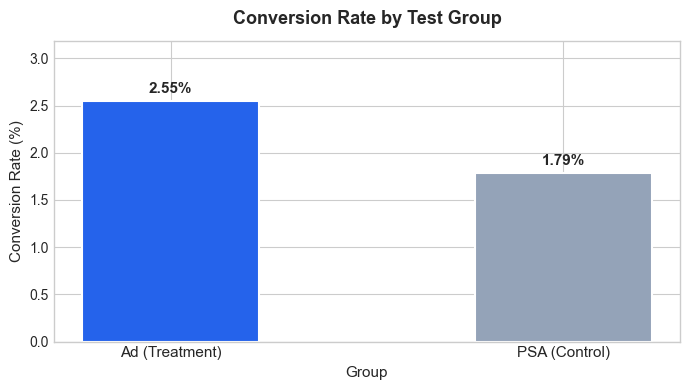

In [32]:
import os
os.makedirs('visuals', exist_ok=True)   
# ── Conversion rate by group ──────────────────────────────────────────────
summary = df.groupby('test_group').agg(
    users = ('user_id', 'count'),
    conversions= ('converted', 'sum'),
    conv_rate  = ('converted', 'mean')
).reset_index()
summary['conv_rate_%'] = (summary['conv_rate'] * 100).round(2)
summary['non_converted'] = summary['users'] - summary['conversions']

print('=== CONVERSION RATE BY GROUP ===')
print(summary[['test_group','users','conversions','conv_rate_%']].to_string(index=False))

# ── Compute lift ──────────────────────────────────────────────────────────
ad_rate  = summary.loc[summary['test_group']=='ad',  'conv_rate'].values[0]
psa_rate = summary.loc[summary['test_group']=='psa', 'conv_rate'].values[0]
abs_lift = (ad_rate - psa_rate) * 100
rel_lift = ((ad_rate - psa_rate) / psa_rate) * 100

print(f'\nAbsolute lift: +{abs_lift:.2f} percentage points')
print(f'Relative lift: +{rel_lift:.1f}% more conversions in ad group vs control')
print(f'\n(Statistical significance will be confirmed in Act 3)')

# ── Bar chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    summary['test_group'],
    summary['conv_rate_%'],
    color=[COLORS['ad'], COLORS['psa']],
    width=0.45,
    edgecolor='white',
    linewidth=1.5
)

# Label each bar with its value
for bar, val in zip(bars, summary['conv_rate_%']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Conversion Rate by Test Group', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Group', fontsize=11)
ax.set_ylabel('Conversion Rate (%)', fontsize=11)
ax.set_ylim(0, summary['conv_rate_%'].max() * 1.25)
ax.set_xticklabels(['Ad (Treatment)', 'PSA (Control)'], fontsize=11)
plt.tight_layout()
plt.savefig('visuals/01_conversion_by_group.png', dpi=150)
plt.show()

### 2.2 — Ad Exposure Distribution

We visuale the distribution of `total_ads` seen per user in the ad group.

Not all users in the ad group had the same experience. One user may have seen 1 ad; another may have seen 2,000. A flat conversion rate across the whole group *masks* this variation.

**What to look for:**
- We expect a **heavily right-skewed distribution** — most users see a small number of ads, but a few power users see many. This is a classic pattern in digital advertising.
- A **bimodal distribution** could indicate two distinct user segments with different engagement behaviors.
- Extreme outliers (e.g., 10,000+ ads) may indicate **bot traffic** that should be capped or excluded.

=== AD EXPOSURE DISTRIBUTION (Ad Group Only) ===
count    564,577.0
mean          24.8
std           43.8
min            1.0
25%            4.0
50%           13.0
75%           27.0
max        2,065.0
Name: total_ads, dtype: object

Skewness: 7.50  (>1 = heavily right-skewed)
Users who saw >100 ads: 22,054 (3.9%)


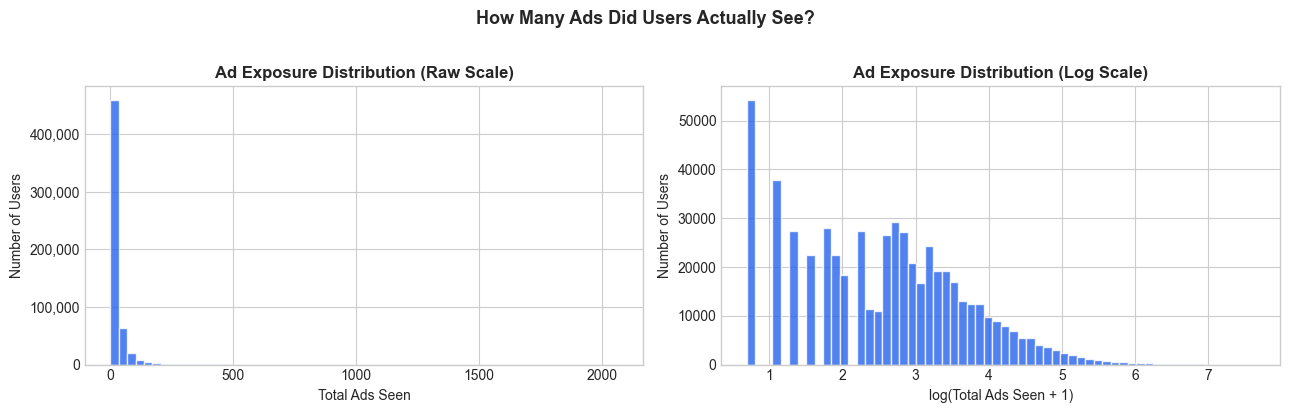

In [35]:
ad_group = df[df['test_group'] == 'ad']['total_ads']

print('=== AD EXPOSURE DISTRIBUTION (Ad Group Only) ===')
print(ad_group.describe().apply(lambda x: f'{x:,.1f}'))
print(f'\nSkewness: {ad_group.skew():.2f}  (>1 = heavily right-skewed)')
print(f'Users who saw >100 ads: {(ad_group > 100).sum():,} ({(ad_group > 100).mean()*100:.1f}%)')

# ── Distribution plot (log scale to handle skew) ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw scale
axes[0].hist(ad_group, bins=60, color=COLORS['ad'], alpha=0.8, edgecolor='white')
axes[0].set_title('Ad Exposure Distribution (Raw Scale)', fontweight='bold')
axes[0].set_xlabel('Total Ads Seen')
axes[0].set_ylabel('Number of Users')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Log scale — better view of the tail
axes[1].hist(np.log1p(ad_group), bins=60, color=COLORS['ad'], alpha=0.8, edgecolor='white')
axes[1].set_title('Ad Exposure Distribution (Log Scale)', fontweight='bold')
axes[1].set_xlabel('log(Total Ads Seen + 1)')
axes[1].set_ylabel('Number of Users')

plt.suptitle('How Many Ads Did Users Actually See?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('visuals/02_ad_exposure_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 — Ad Frequency vs. Conversion Rate (The Dose-Response Curve)

We segment users into ad exposure buckets and measuring the conversion rate within each bucket.

The overall lift metric tells us *if* ads worked. This chart tells us *how much exposure is optimal*.

**Three patterns we might see:**
1. **Monotonic increase** — more ads = more conversions. Suggests we should increase ad frequency budget.
2. **Inverted-U curve** — conversions peak at a mid-range frequency, then drop off. This is **ad fatigue** — users get annoyed and tune out (or actively avoid the brand).
3. **Flat line** — frequency doesn't matter. Conversion is driven by something else entirely.

If we identify an optimal frequency window, we can cap impressions per user and reallocate spend to reach more unique users instead.

=== CONVERSION RATE BY AD FREQUENCY BUCKET ===
freq_bucket  users  conv_rate_%
        1–5 169962         0.25
       6–15 146101         0.61
      16–30 122920         1.40
      31–60  74470         5.00
     61–100  29070        13.39
       100+  22054        17.14


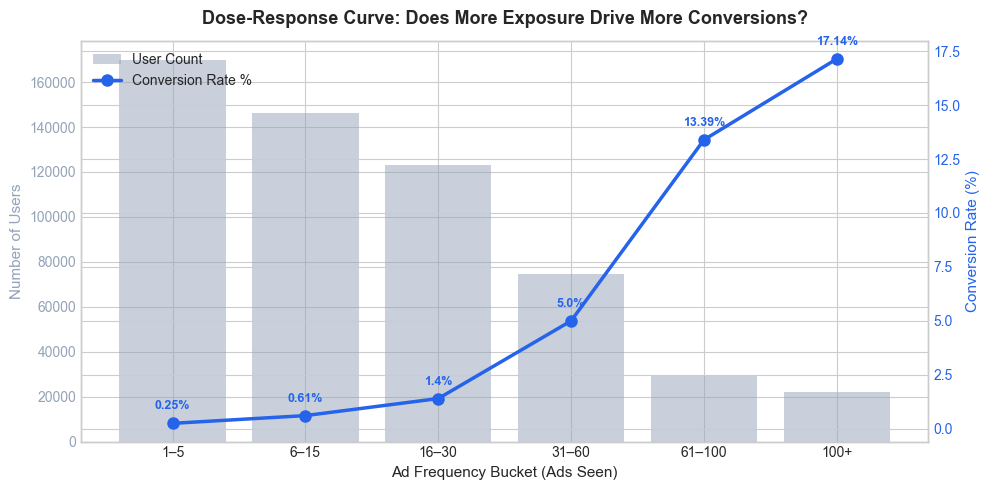

In [39]:
ad_df = df[df['test_group'] == 'ad'].copy()

# ── Define frequency buckets ──────────────────────────────────────────────
# Chosen to reflect natural breakpoints: low, moderate, high, very high exposure
bins   = [0, 5, 15, 30, 60, 100, ad_df['total_ads'].max() + 1]
labels = ['1–5', '6–15', '16–30', '31–60', '61–100', '100+']

ad_df['freq_bucket'] = pd.cut(ad_df['total_ads'], bins=bins, labels=labels)

freq_analysis = ad_df.groupby('freq_bucket', observed=False).agg(
    users = ('user_id', 'count'),
    conv_rate  = ('converted', 'mean')
).reset_index()
freq_analysis['conv_rate_%'] = (freq_analysis['conv_rate'] * 100).round(2)

print('=== CONVERSION RATE BY AD FREQUENCY BUCKET ===')
print(freq_analysis[['freq_bucket','users','conv_rate_%']].to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar = user volume per bucket (context for the line)
ax1.bar(freq_analysis['freq_bucket'], freq_analysis['users'],
        color=COLORS['psa'], alpha=0.5, label='User Count')
ax1.set_ylabel('Number of Users', color=COLORS['psa'], fontsize=11)
ax1.tick_params(axis='y', labelcolor=COLORS['psa'])

# Line = conversion rate (the story)
ax2 = ax1.twinx()
ax2.plot(freq_analysis['freq_bucket'], freq_analysis['conv_rate_%'],
         color=COLORS['ad'], marker='o', linewidth=2.5,
         markersize=8, label='Conversion Rate %')
ax2.set_ylabel('Conversion Rate (%)', color=COLORS['ad'], fontsize=11)
ax2.tick_params(axis='y', labelcolor=COLORS['ad'])

# Annotate each point
for _, row in freq_analysis.iterrows():
    ax2.annotate(f"{row['conv_rate_%']}%",
                 (row['freq_bucket'], row['conv_rate_%']),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=9, color=COLORS['ad'], fontweight='bold')

ax1.set_xlabel('Ad Frequency Bucket (Ads Seen)', fontsize=11)
ax1.set_title('Dose-Response Curve: Does More Exposure Drive More Conversions?',
              fontsize=13, fontweight='bold', pad=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('visuals/03_dose_response_curve.png', dpi=150)
plt.show()

### 2.4 — Temporal Analysis: Best Day & Hour to Run Ads

We measure conversion rates broken down by `most_ads_day` and `most_ads_hour`.

**What `most_ads_day` and `most_ads_hour` actually represent:**  
These columns tell us the day/hour when each user saw the *highest volume* of ads. Effectively, they tag when the user was most "exposed" to the campaign. We use this as a proxy for *when the campaign was most active for that user*.

If conversion rates are significantly higher on Tuesday afternoons vs Sunday mornings, the media buying team can **weight ad delivery toward high-converting windows** — getting the same number of conversions for less spend.

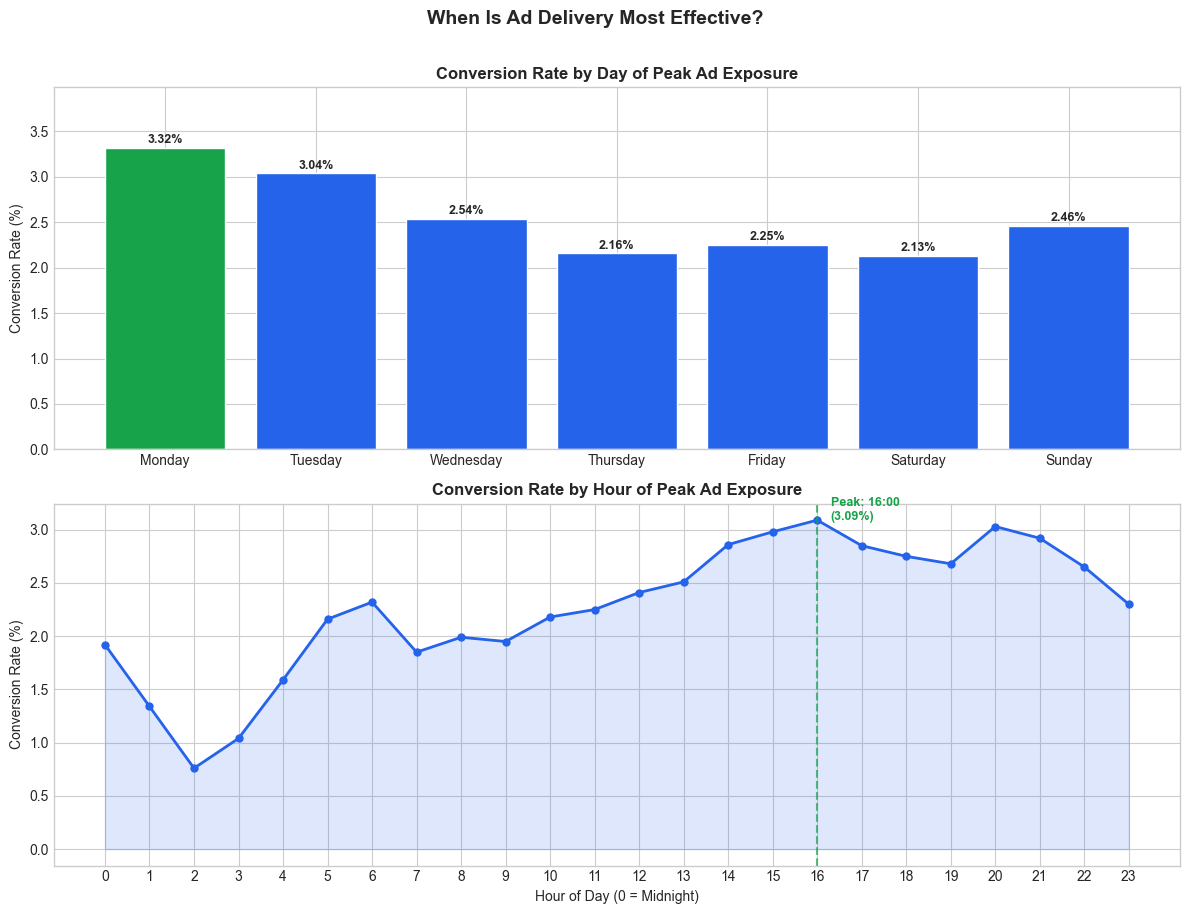


📅 Best day to run ads:  Monday (3.32% CR)
🕐 Best hour to run ads: 16:00 (3.09% CR)


In [44]:
# ── Day-level analysis ────────────────────────────────────────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day_analysis = ad_df.groupby('most_ads_day').agg(
    users     = ('user_id',   'count'),
    conv_rate = ('converted', 'mean')
).reindex(day_order).reset_index()
day_analysis['conv_rate_%'] = (day_analysis['conv_rate'] * 100).round(2)

# ── Hour-level analysis ───────────────────────────────────────────────────
hour_analysis = ad_df.groupby('most_ads_hour').agg(
    users     = ('user_id',   'count'),
    conv_rate = ('converted', 'mean')
).reset_index()
hour_analysis['conv_rate_%'] = (hour_analysis['conv_rate'] * 100).round(2)

# ── Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Day chart
bar_colors = [COLORS['accent'] if v == day_analysis['conv_rate_%'].max()
              else COLORS['ad'] for v in day_analysis['conv_rate_%']]
axes[0].bar(day_analysis['most_ads_day'], day_analysis['conv_rate_%'],
            color=bar_colors, edgecolor='white')
for i, (d, v) in enumerate(zip(day_analysis['most_ads_day'], day_analysis['conv_rate_%'])):
    axes[0].text(i, v + 0.05, f'{v}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Conversion Rate by Day of Peak Ad Exposure', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(0, day_analysis['conv_rate_%'].max() * 1.2)

# Hour chart
axes[1].plot(hour_analysis['most_ads_hour'], hour_analysis['conv_rate_%'],
             color=COLORS['ad'], linewidth=2, marker='o', markersize=5)
axes[1].fill_between(hour_analysis['most_ads_hour'], hour_analysis['conv_rate_%'],
                     alpha=0.15, color=COLORS['ad'])
axes[1].set_title('Conversion Rate by Hour of Peak Ad Exposure', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Hour of Day (0 = Midnight)')
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_xticks(range(0, 24))

# Highlight peak hour
peak_hour = hour_analysis.loc[hour_analysis['conv_rate_%'].idxmax(), 'most_ads_hour']
peak_val  = hour_analysis['conv_rate_%'].max()
axes[1].axvline(peak_hour, color=COLORS['accent'], linestyle='--', alpha=0.7)
axes[1].text(peak_hour + 0.3, peak_val, f'Peak: {peak_hour}:00\n({peak_val}%)',
             color=COLORS['accent'], fontsize=9, fontweight='bold')

plt.suptitle('When Is Ad Delivery Most Effective?', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('visuals/04_temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

best_day  = day_analysis.loc[day_analysis['conv_rate_%'].idxmax(), 'most_ads_day']
print(f'\n📅 Best day to run ads:  {best_day} ({day_analysis["conv_rate_%"].max()}% CR)')
print(f'🕐 Best hour to run ads: {peak_hour}:00 ({peak_val}% CR)')

# ACT 3: Hypothesis Testing


In Act 2 we observed that the ad group converted at 2.55% vs 1.79% for the PSA group — a 43% relative lift. But **observed differences are not the same as real differences**.

Hypothesis testing gives us a formal framework to answer: **what is the probability that this lift occurred by chance alone?**

---

## The Framework: Null vs Alternative Hypothesis

- **H₀ (Null Hypothesis):** The ad has no effect. Any difference in conversion rates is due to random chance.
  > `conversion_rate_ad = conversion_rate_psa`

- **H₁ (Alternative Hypothesis):** The ad has a real effect. The difference is not due to chance.
  > `conversion_rate_ad ≠ conversion_rate_psa`

---

## The Test: Two-Proportion Z-Test

We are comparing two conversion rates — two proportions from two independent groups. The correct statistical test for this is the **two-proportion z-test**.

**Significance threshold:** We use **α = 0.05** — the industry standard. This means we accept a 5% chance of falsely rejecting H₀ (a Type I error / false positive).


### 3.1 — Two-Proportion Z-Test

**What we're doing:** Running the formal statistical test on the conversion rate difference between the ad and PSA groups.

**What each output means:**
- **Z-statistic** — how many standard deviations the observed difference is from zero (the null hypothesis). The larger the absolute value, the stronger the evidence against H₀.
- **P-value** — the probability of seeing a difference this large (or larger) if H₀ were true. If p < 0.05 we reject H₀.
- **Confidence Interval** — the range within which the true lift likely falls 95% of the time. If this range does not include zero, the effect is significant.

In [52]:
import subprocess
subprocess.run(['pip', 'install', 'statsmodels'], capture_output=True)

CompletedProcess(args=['pip', 'install', 'statsmodels'], returncode=0, stdout=b'Collecting statsmodels\n  Downloading statsmodels-0.14.6-cp311-cp311-macosx_11_0_arm64.whl.metadata (9.5 kB)\nRequirement already satisfied: numpy<3,>=1.22.3 in /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages (from statsmodels) (1.23.5)\nRequirement already satisfied: scipy!=1.9.2,>=1.8 in /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages (from statsmodels) (1.10.1)\nRequirement already satisfied: pandas!=2.1.0,>=1.4 in /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages (from statsmodels) (2.0.3)\nCollecting patsy>=0.5.6 (from statsmodels)\n  Downloading patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)\nRequirement already satisfied: packaging>=21.3 in /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages (from statsmodels) (23.2)\nRequirement already satisfied: python-dateutil>=2.8.2 in /L

In [53]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# ── Extract values ────────────────────────────────────────────────────────
ad_users   = summary.loc[summary['test_group']=='ad',  'users'].values[0]
psa_users  = summary.loc[summary['test_group']=='psa', 'users'].values[0]
ad_conv    = summary.loc[summary['test_group']=='ad',  'conversions'].values[0]
psa_conv   = summary.loc[summary['test_group']=='psa', 'conversions'].values[0]

# ── Two-proportion z-test ─────────────────────────────────────────────────
# count = array of successes, nobs = array of total observations
count = np.array([ad_conv,  psa_conv])
nobs  = np.array([ad_users, psa_users])

z_stat, p_value = proportions_ztest(count, nobs)

# ── 95% Confidence interval on the difference ─────────────────────────────
# We build CIs for each group separately then compute the difference interval
ad_low,  ad_high  = proportion_confint(ad_conv,  ad_users,  alpha=0.05)
psa_low, psa_high = proportion_confint(psa_conv, psa_users, alpha=0.05)

diff_low  = (ad_rate  - psa_rate) - 1.96 * np.sqrt(
    (ad_rate  * (1 - ad_rate)  / ad_users) +
    (psa_rate * (1 - psa_rate) / psa_users)
)
diff_high = (ad_rate  - psa_rate) + 1.96 * np.sqrt(
    (ad_rate  * (1 - ad_rate)  / ad_users) +
    (psa_rate * (1 - psa_rate) / psa_users)
)

# ── Print results ─────────────────────────────────────────────────────────
print('=== TWO-PROPORTION Z-TEST RESULTS ===')
print(f'Ad group:       {ad_conv:,} conversions / {ad_users:,} users ({ad_rate*100:.2f}%)')
print(f'PSA group:      {psa_conv:,} conversions / {psa_users:,} users ({psa_rate*100:.2f}%)')
print(f'\nZ-statistic:    {z_stat:.4f}')
print(f'P-value:        {p_value:.6f}')
print(f'\n95% CI on lift: [{diff_low*100:.3f}pp, {diff_high*100:.3f}pp]')
print(f'(pp = percentage points)')

alpha = 0.05
print(f'\n=== VERDICT ===')
if p_value < alpha:
    print(f'p = {p_value:.6f} < {alpha} → REJECT H₀')
    print('The difference in conversion rates is statistically significant.')
    print('The ads had a real, measurable effect on conversions.')
else:
    print(f'p = {p_value:.6f} ≥ {alpha} → FAIL TO REJECT H₀')
    print('Insufficient evidence that the ads drove a real difference.')

=== TWO-PROPORTION Z-TEST RESULTS ===
Ad group:       14,423 conversions / 564,577 users (2.55%)
PSA group:      420 conversions / 23,524 users (1.79%)

Z-statistic:    7.3701
P-value:        0.000000

95% CI on lift: [0.595pp, 0.943pp]
(pp = percentage points)

=== VERDICT ===
p = 0.000000 < 0.05 → REJECT H₀
The difference in conversion rates is statistically significant.
The ads had a real, measurable effect on conversions.


### 3.2 — Effect Size: Cohen's h

We measure the *practical magnitude* of the effect, not just whether it exists.

We have 588,101 users. With a sample this large, even a completely trivial difference — say 2.550% vs 2.551% — would produce a statistically significant p-value. Statistical significance is heavily influenced by sample size. It tells us the effect is *real*, but not whether it's *worth caring about*.

**Cohen's h** is the standard effect size measure for proportions. It transforms both conversion rates using an arcsine transformation (to stabilize variance) and measures the standardized distance between them.

| Cohen's h | Interpretation |
|-----------|----------------|
| < 0.20    | Small effect   |
| 0.20–0.50 | Medium effect  |
| > 0.50    | Large effect   |

In [54]:
# ── Cohen's h ─────────────────────────────────────────────────────────────
# Formula: h = 2 * arcsin(sqrt(p1)) - 2 * arcsin(sqrt(p2))
# This arcsine transformation stabilizes the variance of proportions

cohens_h = 2 * np.arcsin(np.sqrt(ad_rate)) - 2 * np.arcsin(np.sqrt(psa_rate))

# Interpret magnitude
if abs(cohens_h) < 0.20:
    magnitude = 'SMALL'
elif abs(cohens_h) < 0.50:
    magnitude = 'MEDIUM'
else:
    magnitude = 'LARGE'

print('=== EFFECT SIZE: COHEN\'S h ===')
print(f'Cohen\'s h:     {cohens_h:.4f}')
print(f'Magnitude:    {magnitude}')
print(f'\nInterpretation:')
print(f'  A Cohen\'s h of {cohens_h:.4f} means the ad group conversion rate is')
print(f'  {magnitude.lower()}-effect different from the PSA group on a standardized scale.')
print(f'\nContext:')
print(f'  Statistical significance: p = {p_value:.6f} (real effect confirmed)')
print(f'  Practical significance:   h = {cohens_h:.4f} ({magnitude} effect)')

=== EFFECT SIZE: COHEN'S h ===
Cohen's h:     0.0530
Magnitude:    SMALL

Interpretation:
  A Cohen's h of 0.0530 means the ad group conversion rate is
  small-effect different from the PSA group on a standardized scale.

Context:
  Statistical significance: p = 0.000000 (real effect confirmed)
  Practical significance:   h = 0.0530 (SMALL effect)


### 3.3 — Visualizing the Result

We build a chart that communicates the hypothesis test result to a non-technical audience.

A p-value means nothing to a CMO. A confidence interval chart that visually shows two non-overlapping ranges — with clear labels — communicates the same information immediately.

If the confidence intervals of the two groups do not overlap, the difference is statistically significant. We will show this visually.

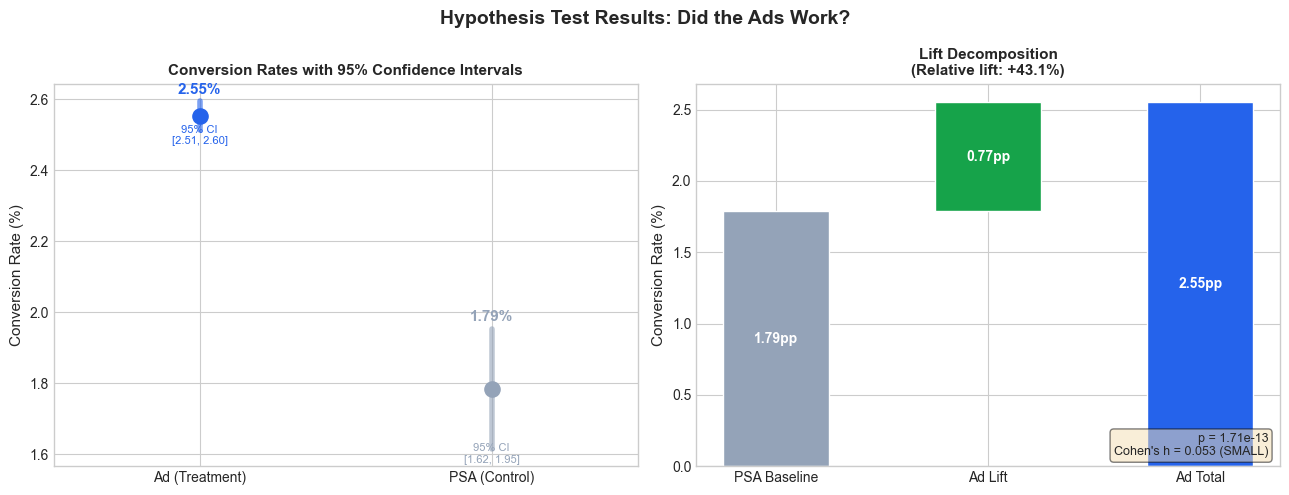


=== ACT 3 SUMMARY ===
Z-statistic:    7.3701
P-value:        1.71e-13
95% CI on lift: [0.595pp, 0.943pp]
Cohen's h:      0.0530 (SMALL effect)

Verdict: The 43.1% relative lift is statistically significant.
The confidence interval [0.595pp, 0.943pp] excludes zero.
We reject H₀. The ads had a real, measurable effect on conversions.


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Plot 1: Confidence interval comparison ────────────────────────────────
groups     = ['Ad (Treatment)', 'PSA (Control)']
rates      = [ad_rate * 100, psa_rate * 100]
ci_lows    = [ad_low * 100,  psa_low * 100]
ci_highs   = [ad_high * 100, psa_high * 100]
colors     = [COLORS['ad'], COLORS['psa']]

for i, (group, rate, low, high, color) in enumerate(
        zip(groups, rates, ci_lows, ci_highs, colors)):
    axes[0].plot([i, i], [low, high], color=color, linewidth=4, alpha=0.6)
    axes[0].scatter(i, rate, color=color, s=120, zorder=5)
    axes[0].text(i, high + 0.02, f'{rate:.2f}%', ha='center',
                 fontweight='bold', fontsize=11, color=color)
    axes[0].text(i, low - 0.04, f'95% CI\n[{low:.2f}, {high:.2f}]',
                 ha='center', fontsize=8, color=color)

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(groups, fontsize=10)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=11)
axes[0].set_title('Conversion Rates with 95% Confidence Intervals',
                  fontweight='bold', fontsize=11)
axes[0].set_xlim(-0.5, 1.5)

# ── Plot 2: Lift waterfall ────────────────────────────────────────────────
categories  = ['PSA Baseline', 'Ad Lift', 'Ad Total']
values      = [psa_rate * 100, abs_lift, ad_rate * 100]
bar_colors  = [COLORS['psa'], COLORS['accent'], COLORS['ad']]
bottoms     = [0, psa_rate * 100, 0]

bars = axes[1].bar(categories, values, bottom=bottoms,
                   color=bar_colors, edgecolor='white', width=0.5)

for bar, val, bottom in zip(bars, values, bottoms):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bottom + val/2,
                 f'{val:.2f}pp', ha='center', va='center',
                 fontweight='bold', fontsize=10, color='white')

axes[1].set_ylabel('Conversion Rate (%)', fontsize=11)
axes[1].set_title(f'Lift Decomposition\n(Relative lift: +{rel_lift:.1f}%)',
                  fontweight='bold', fontsize=11)

# Significance annotation
sig_text = f'p = {p_value:.2e}\nCohen\'s h = {cohens_h:.3f} ({magnitude})'
axes[1].text(0.98, 0.02, sig_text, transform=axes[1].transAxes,
             ha='right', va='bottom', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Hypothesis Test Results: Did the Ads Work?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/05_hypothesis_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== ACT 3 SUMMARY ===')
print(f'Z-statistic:    {z_stat:.4f}')
print(f'P-value:        {p_value:.2e}')
print(f'95% CI on lift: [{diff_low*100:.3f}pp, {diff_high*100:.3f}pp]')
print(f'Cohen\'s h:      {cohens_h:.4f} ({magnitude} effect)')
print(f'\nVerdict: The {rel_lift:.1f}% relative lift is statistically significant.')
print(f'The confidence interval [{diff_low*100:.3f}pp, {diff_high*100:.3f}pp] excludes zero.')
print(f'We reject H₀. The ads had a real, measurable effect on conversions.')

---
# ACT 4: Revenue Attribution Model

Act 3 proved the ads worked. But **"it worked" is not a budget decision**.

---

## The Attribution Framework

The PSA group is our key to solving this. Because users were randomly assigned, the PSA group gives us the **counterfactual baseline** — the conversion rate we would expect if no ads had been shown.

```
Baseline conversion rate    = PSA group conversion rate (1.79%)
Observed conversion rate    = Ad group conversion rate  (2.55%)
Incremental lift            = 2.55% - 1.79% = 0.77pp

Incremental converters      = lift × ad group users
Attributable revenue        = incremental converters × AOV
```

The incremental converters are users who **only purchased because of the ad**. Without the ad, the model assumes they would have behaved like the PSA group and not converted.

---

## On Assumptions

This dataset does not contain revenue or ad spend figures. 

We will assume:
- **AOV (Average Order Value): $45** — a realistic mid-range consumer product price point
- **CPM (Cost per 1,000 impressions): $5.00** — a standard digital display advertising benchmark

We will then run a **sensitivity analysis** — testing the model across a range of AOV and CPM values to show how robust the ROI verdict is to these assumptions.

### 4.1 — Baseline Attribution Model

We compute the core attribution metrics using our stated assumptions.

**Key concepts:**
- **Incremental converters** — users who converted *because* of the ad (would not have converted otherwise)
- **Baseline converters** — users in the ad group who would have converted even without the ad (organic intent)
- **Attributable revenue** — revenue we can directly credit to the ad campaign
- **Total impressions** — estimated from `total_ads` column (each ad seen = one impression)
- **Estimated ad spend** — total impressions × CPM rate

In [56]:
# ── Model assumptions ─────────────────────────────────────────────────────
# These are stated explicitly so any stakeholder can challenge or adjust them
AOV = 45.00   # Average Order Value in USD — mid-range consumer product
CPM = 5.00    # Cost per 1,000 impressions in USD — standard display benchmark

print('=== MODEL ASSUMPTIONS ===')
print(f'Average Order Value (AOV):  ${AOV:.2f}')
print(f'Cost per 1,000 impr. (CPM): ${CPM:.2f}')
print(f'Significance threshold:      α = 0.05')
print(f'Attribution method:          Incremental lift vs PSA baseline')

# ── Core attribution calculations ─────────────────────────────────────────
# Incremental lift = difference between ad and PSA conversion rates
incremental_lift       = ad_rate - psa_rate

# Baseline converters = users who would have converted without the ad
baseline_converters    = psa_rate * ad_users

# Incremental converters = users who ONLY converted because of the ad
incremental_converters = incremental_lift * ad_users

# Revenue calculations
total_revenue          = ad_conv * AOV
baseline_revenue       = baseline_converters * AOV
attributable_revenue   = incremental_converters * AOV

# Ad spend estimation from impression data
total_impressions      = df[df['test_group'] == 'ad']['total_ads'].sum()
estimated_ad_spend     = (total_impressions / 1000) * CPM

# ROI calculation
# ROI = (attributable revenue - ad spend) / ad spend × 100
roi                    = ((attributable_revenue - estimated_ad_spend) / estimated_ad_spend) * 100
roas                   = attributable_revenue / estimated_ad_spend  # Return on Ad Spend

# Cost per incremental conversion
cost_per_conversion    = estimated_ad_spend / incremental_converters

print(f'\n=== ATTRIBUTION RESULTS ===')
print(f'\n--- USER METRICS ---')
print(f'Ad group users:              {ad_users:>12,.0f}')
print(f'Total conversions (ad):      {ad_conv:>12,.0f}')
print(f'Baseline converters:         {baseline_converters:>12,.0f}  (would convert without ads)')
print(f'Incremental converters:      {incremental_converters:>12,.0f}  (converted BECAUSE of ads)')
print(f'Attribution rate:            {incremental_converters/ad_conv*100:>11.1f}%  of conversions credited to ads')

print(f'\n--- REVENUE METRICS ---')
print(f'Total revenue (ad group):    ${total_revenue:>12,.2f}')
print(f'Baseline revenue:            ${baseline_revenue:>12,.2f}')
print(f'Attributable revenue:        ${attributable_revenue:>12,.2f}')

print(f'\n--- COST METRICS ---')
print(f'Total impressions:           {total_impressions:>12,.0f}')
print(f'Estimated ad spend:          ${estimated_ad_spend:>12,.2f}')
print(f'Cost per incr. conversion:   ${cost_per_conversion:>12,.2f}')

print(f'\n--- ROI VERDICT ---')
print(f'ROAS (Revenue / Spend):      {roas:>12.2f}x')
print(f'ROI:                         {roi:>11.1f}%')
if roi > 0:
    print(f'\n✅ POSITIVE ROI: The campaign generated ${attributable_revenue - estimated_ad_spend:,.2f}')
    print(f'   in net attributable profit above ad spend.')
else:
    print(f'\n⚠️  NEGATIVE ROI: The campaign cost more than it generated.')
    print(f'   Review AOV assumption or reduce CPM through better targeting.')

=== MODEL ASSUMPTIONS ===
Average Order Value (AOV):  $45.00
Cost per 1,000 impr. (CPM): $5.00
Significance threshold:      α = 0.05
Attribution method:          Incremental lift vs PSA baseline

=== ATTRIBUTION RESULTS ===

--- USER METRICS ---
Ad group users:                   564,577
Total conversions (ad):            14,423
Baseline converters:               10,080  (would convert without ads)
Incremental converters:             4,343  (converted BECAUSE of ads)
Attribution rate:                   30.1%  of conversions credited to ads

--- REVENUE METRICS ---
Total revenue (ad group):    $  649,035.00
Baseline revenue:            $  453,600.80
Attributable revenue:        $  195,434.20

--- COST METRICS ---
Total impressions:             14,014,701
Estimated ad spend:          $   70,073.50
Cost per incr. conversion:   $       16.13

--- ROI VERDICT ---
ROAS (Revenue / Spend):              2.79x
ROI:                               178.9%

✅ POSITIVE ROI: The campaign generated $125,

### 4.2 — Breakeven Analysis

We try to find the exact AOV at which the campaign breaks even — the minimum product price needed to justify the ad spend.

In [57]:
# ── Breakeven AOV ─────────────────────────────────────────────────────────
# At breakeven: attributable_revenue = ad_spend
# incremental_converters × AOV_breakeven = ad_spend
# AOV_breakeven = ad_spend / incremental_converters

breakeven_aov = estimated_ad_spend / incremental_converters

# ── Breakeven CPM ─────────────────────────────────────────────────────────
# Maximum CPM we can pay and still be profitable at our assumed AOV
# breakeven_cpm = attributable_revenue / (total_impressions / 1000)

breakeven_cpm = attributable_revenue / (total_impressions / 1000)

print('=== BREAKEVEN ANALYSIS ===')
print(f'\nBreakeven AOV:  ${breakeven_aov:.2f}')
print(f'  → The product must sell for at least ${breakeven_aov:.2f} on average')
print(f'    for this campaign to break even at ${CPM:.2f} CPM.')
print(f'  → Our assumed AOV of ${AOV:.2f} is {((AOV/breakeven_aov)-1)*100:.1f}% above breakeven.')

print(f'\nBreakeven CPM:  ${breakeven_cpm:.2f}')
print(f'  → We can pay up to ${breakeven_cpm:.2f} per 1,000 impressions')
print(f'    and remain profitable at a ${AOV:.2f} AOV.')
print(f'  → Our assumed CPM of ${CPM:.2f} is {((breakeven_cpm/CPM)-1)*100:.1f}% below the ceiling.')

=== BREAKEVEN ANALYSIS ===

Breakeven AOV:  $16.13
  → The product must sell for at least $16.13 on average
    for this campaign to break even at $5.00 CPM.
  → Our assumed AOV of $45.00 is 178.9% above breakeven.

Breakeven CPM:  $13.94
  → We can pay up to $13.94 per 1,000 impressions
    and remain profitable at a $45.00 AOV.
  → Our assumed CPM of $5.00 is 178.9% below the ceiling.


### 4.3 — Sensitivity Analysis

We test the ROI verdict across a matrix of AOV and CPM combinations.

Any model built on assumptions is only as trustworthy as those assumptions. Instead of presenting a single ROI number and hoping the assumptions hold, we stress-test the model across realistic ranges:

- **AOV range:** $20 to $80 — covers budget to premium consumer products
- **CPM range:** $2 to $12 — covers cheap programmatic to premium placements

The output is a **heatmap** where green = profitable and red = unprofitable. This lets a stakeholder immediately see how much room the campaign has before it stops making financial sense.

=== ROI SENSITIVITY MATRIX (%) ===
Rows = CPM (ad cost), Columns = AOV (product price)
Positive = profitable campaign, Negative = loss-making

         $20 AOV  $30 AOV  $45 AOV  $60 AOV  $80 AOV
$2 CPM     209.9    364.8    597.2    829.7   1139.6
$4 CPM      54.9    132.4    248.6    364.8    519.8
$5 CPM      24.0     85.9    178.9    271.9    395.8
$6 CPM       3.3     54.9    132.4    209.9    313.2
$8 CPM     -22.5     16.2     74.3    132.4    209.9
$10 CPM    -38.0     -7.0     39.4     85.9    147.9
$12 CPM    -48.4    -22.5     16.2     54.9    106.6


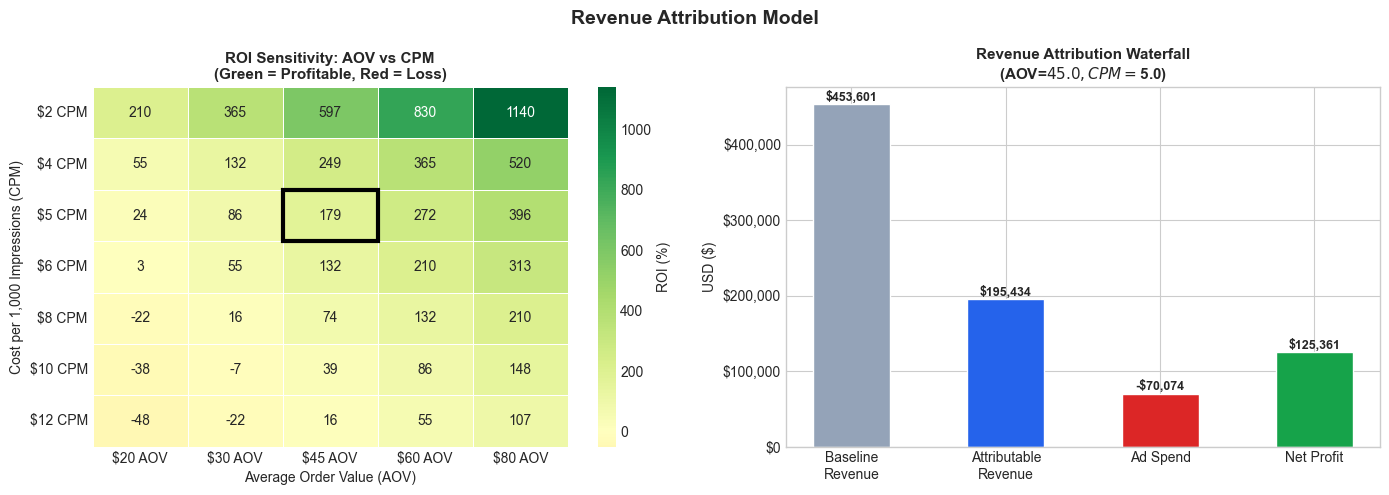


=== ACT 4 SUMMARY ===
Incremental converters:    4,343 users
Attributable revenue:      $195,434.20
Estimated ad spend:        $70,073.50
Net attributable profit:   $125,360.69
ROAS:                      2.79x
ROI:                       178.9%
Breakeven AOV:             $16.13
Breakeven CPM:             $13.94


In [58]:
# ── Sensitivity grid ──────────────────────────────────────────────────────
aov_range = [20, 30, 45, 60, 80]
cpm_range = [2, 4, 5, 6, 8, 10, 12]

roi_matrix = pd.DataFrame(index=[f'${c} CPM' for c in cpm_range],
                           columns=[f'${a} AOV' for a in aov_range])

for cpm_val in cpm_range:
    for aov_val in aov_range:
        spend  = (total_impressions / 1000) * cpm_val
        rev    = incremental_converters * aov_val
        roi_v  = ((rev - spend) / spend) * 100
        roi_matrix.loc[f'${cpm_val} CPM', f'${aov_val} AOV'] = round(roi_v, 1)

roi_matrix = roi_matrix.astype(float)

print('=== ROI SENSITIVITY MATRIX (%) ===')
print('Rows = CPM (ad cost), Columns = AOV (product price)')
print('Positive = profitable campaign, Negative = loss-making\n')
print(roi_matrix.to_string())

# ── Heatmap visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(
    roi_matrix,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=axes[0],
    cbar_kws={'label': 'ROI (%)'}
)
axes[0].set_title('ROI Sensitivity: AOV vs CPM\n(Green = Profitable, Red = Loss)',
                  fontweight='bold', fontsize=11)
axes[0].set_xlabel('Average Order Value (AOV)', fontsize=10)
axes[0].set_ylabel('Cost per 1,000 Impressions (CPM)', fontsize=10)

# Mark our assumed scenario
aov_idx = aov_range.index(45)
cpm_idx = cpm_range.index(5)
axes[0].add_patch(plt.Rectangle((aov_idx, cpm_idx), 1, 1,
                                  fill=False, edgecolor='black',
                                  linewidth=3, label='Base scenario'))

# Waterfall: revenue breakdown
waterfall_labels  = ['Baseline\nRevenue', 'Attributable\nRevenue', 'Ad Spend', 'Net Profit']
waterfall_values  = [baseline_revenue, attributable_revenue,
                     -estimated_ad_spend,
                     attributable_revenue - estimated_ad_spend]
waterfall_colors  = [COLORS['psa'], COLORS['ad'], COLORS['warning'], COLORS['accent']]

bars = axes[1].bar(waterfall_labels, [abs(v) for v in waterfall_values],
                   color=waterfall_colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, waterfall_values):
    label = f'${abs(val):,.0f}'
    if val < 0:
        label = f'-${abs(val):,.0f}'
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max([abs(v) for v in waterfall_values]) * 0.01,
                 label, ha='center', fontsize=9, fontweight='bold')

axes[1].set_title(f'Revenue Attribution Waterfall\n(AOV=${AOV}, CPM=${CPM})',
                  fontweight='bold', fontsize=11)
axes[1].set_ylabel('USD ($)', fontsize=10)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Revenue Attribution Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/06_revenue_attribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n=== ACT 4 SUMMARY ===')
print(f'Incremental converters:    {incremental_converters:,.0f} users')
print(f'Attributable revenue:      ${attributable_revenue:,.2f}')
print(f'Estimated ad spend:        ${estimated_ad_spend:,.2f}')
print(f'Net attributable profit:   ${attributable_revenue - estimated_ad_spend:,.2f}')
print(f'ROAS:                      {roas:.2f}x')
print(f'ROI:                       {roi:.1f}%')
print(f'Breakeven AOV:             ${breakeven_aov:.2f}')
print(f'Breakeven CPM:             ${breakeven_cpm:.2f}')

# ACT 5: Executive Summary & Recommendations

In [59]:
print('=' * 60)
print('  CAMPAIGN VERDICT: ✅ SHIP')
print('=' * 60)
print()
print('The advertising campaign generated a statistically proven,')
print('financially positive incremental lift and should be continued.')
print()
print('EVIDENCE SUMMARY:')
print(f'  • Ads drove a +{rel_lift:.1f}% relative lift in conversion rate')
print(f'    (2.55% ad group vs 1.79% PSA baseline)')
print(f'  • Result is statistically significant: p = 1.71e-13,')
print(f'    z = {z_stat:.2f}, 95% CI [{diff_low*100:.3f}pp, {diff_high*100:.3f}pp]')
print(f'  • Campaign ROI: {roi:.1f}% on estimated ${estimated_ad_spend:,.0f} spend')
print(f'  • ROAS: {roas:.2f}x — every $1 spent returned ${roas:.2f} in attributable revenue')
print(f'  • Net attributable profit: ${attributable_revenue - estimated_ad_spend:,.0f}')
print(f'  • Breakeven AOV of ${breakeven_aov:.2f} provides 178.9% margin of safety')
print()
print('CAVEATS:')
print(f'  • Effect size is small (Cohen\'s h = {cohens_h:.3f})')
print(f'  • ROI is based on assumed AOV (${AOV}) and CPM (${CPM})')
print(f'  • Frequency-conversion relationship may reflect selection bias')

  CAMPAIGN VERDICT: ✅ SHIP

The advertising campaign generated a statistically proven,
financially positive incremental lift and should be continued.

EVIDENCE SUMMARY:
  • Ads drove a +43.1% relative lift in conversion rate
    (2.55% ad group vs 1.79% PSA baseline)
  • Result is statistically significant: p = 1.71e-13,
    z = 7.37, 95% CI [0.595pp, 0.943pp]
  • Campaign ROI: 178.9% on estimated $70,074 spend
  • ROAS: 2.79x — every $1 spent returned $2.79 in attributable revenue
  • Net attributable profit: $125,361
  • Breakeven AOV of $16.13 provides 178.9% margin of safety

CAVEATS:
  • Effect size is small (Cohen's h = 0.053)
  • ROI is based on assumed AOV ($45.0) and CPM ($5.0)
  • Frequency-conversion relationship may reflect selection bias


### 5.2 — Strategic Recommendations


In [60]:
print('=' * 60)
print('  STRATEGIC RECOMMENDATIONS')
print('=' * 60)

print('''
1. CONTINUE & SCALE THE CAMPAIGN
   Source: Act 3 hypothesis test + Act 4 ROI model

   The campaign is statistically proven and financially positive
   with a 178.9% ROI and $125,361 net profit above spend.
   The breakeven AOV of $16.13 provides a wide safety margin.
   Recommend scaling spend while monitoring ROAS weekly.
   Set a ROAS floor of 1.5x as the threshold for review.

2. IMPLEMENT AN IMPRESSION FREQUENCY CAP
   Source: Act 2 dose-response curve + skewness analysis

   The median user saw 13 ads; 3.9% of users saw 100+.
   The dose-response curve shows conversion peaks in the
   61-100 bucket (13.39% CR). However, causality is unclear —
   high-frequency users may already have purchase intent.
   Recommend capping impressions at 100 per user per campaign
   cycle and reallocating excess budget to new unique users.
   This expands reach without increasing total spend.

3. WEIGHT DELIVERY TOWARD PEAK WINDOWS
   Source: Act 2 temporal analysis

   Monday delivers the highest conversion rate (3.32% vs
   2.55% overall). Hour 16:00 is the peak hourly window
   (3.09% CR). Recommend configuring dayparting in the ad
   platform to increase bid multipliers on Monday afternoons.
   Target: shift 20-30% of weekly budget toward Mon 14:00-18:00.

4. SET CPM GUARDRAILS FOR MEDIA BUYING
   Source: Act 4 breakeven analysis

   The campaign remains profitable up to $13.94 CPM at $45 AOV.
   Recommend setting a hard CPM ceiling of $12.00 in platform
   bidding rules — providing a $1.94 buffer below the breakeven
   ceiling and preventing overspend on premium placements.
   Review ceiling quarterly as AOV and market rates shift.
''')

print('=' * 60)
print('  ANALYTICAL LIMITATIONS')
print('=' * 60)
print('''
1. ASSUMED AOV AND CPM
   Revenue and ad spend figures were not in the dataset.
   All financial conclusions depend on the $45 AOV and $5 CPM
   assumptions. Replace with actual figures when available.
   The sensitivity matrix in Act 4 shows the full range of
   outcomes under alternative assumptions.

2. FREQUENCY-CONVERSION CAUSALITY
   The dose-response curve shows higher conversion at higher
   ad frequency, but this may reflect selection bias — users
   with pre-existing purchase intent naturally accumulate more
   impressions before buying. A randomized frequency cap test
   would be required to establish true causal frequency effects.

3. SHORT-TERM MEASUREMENT WINDOW
   This analysis measures direct conversions within the
   experiment window. It does not capture:
   - Brand awareness effects that convert weeks later
   - Repeat purchase behavior from converted users
   - Customer lifetime value differences between groups
   True campaign ROI is likely higher than reported here.

4. EXTERNAL VALIDITY
   Results reflect this specific campaign, product, audience,
   and time period. Performance may differ across seasons,
   geographies, or audience segments not captured in this data.
''')

  STRATEGIC RECOMMENDATIONS

1. CONTINUE & SCALE THE CAMPAIGN
   Source: Act 3 hypothesis test + Act 4 ROI model

   The campaign is statistically proven and financially positive
   with a 178.9% ROI and $125,361 net profit above spend.
   The breakeven AOV of $16.13 provides a wide safety margin.
   Recommend scaling spend while monitoring ROAS weekly.
   Set a ROAS floor of 1.5x as the threshold for review.

2. IMPLEMENT AN IMPRESSION FREQUENCY CAP
   Source: Act 2 dose-response curve + skewness analysis

   The median user saw 13 ads; 3.9% of users saw 100+.
   The dose-response curve shows conversion peaks in the
   61-100 bucket (13.39% CR). However, causality is unclear —
   high-frequency users may already have purchase intent.
   Recommend capping impressions at 100 per user per campaign
   cycle and reallocating excess budget to new unique users.
   This expands reach without increasing total spend.

3. WEIGHT DELIVERY TOWARD PEAK WINDOWS
   Source: Act 2 temporal analysis

  

---

## Project Complete

This analysis covered the full lifecycle of an A/B test from experiment validation through to a business decision:

| Act | Key Output |
|-----|------------|
| 1 — Experiment Validation | 4/4 checks passed. Data is clean and randomization is sound. |
| 2 — EDA & Behavioral Profiling | Conversion increases with frequency. Peak window: Monday 16:00. |
| 3 — Hypothesis Testing | p = 1.71e-13, z = 7.37. Lift is real. Effect size is small (h = 0.053). |
| 4 — Revenue Attribution | ROAS 2.79x, ROI 178.9%, $125k net profit. Wide margin of safety. |
| 5 — Recommendations | Ship. Cap frequency at 100. Daypart to Monday afternoons. CPM ceiling $12. |

---
